In [6]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [7]:
# --- Load the new dataset and auto-map columns to the expected schema ---
df = pd.read_csv('household_load_start_end.csv')

# Automatic column mapping: find the timestamp column and the load/consumption column
# regardless of naming differences, so this cell keeps working if the source file changes.
col_map = {}
for col in df.columns:
    cl = col.strip().lower()
    if cl in ('start', 'timestamp', 'datetime', 'date', 'time'):
        col_map[col] = 'start'
    elif cl in ('load', 'consumption', 'usage', 'value', 'kwh', 'energy'):
        col_map[col] = 'load'

df = df.rename(columns=col_map)

# Basic validation / cleanup so the rest of the pipeline (unchanged below) keeps working
assert 'start' in df.columns and 'load' in df.columns, \
    f"Could not find required 'start'/'load' columns after mapping. Got: {list(df.columns)}"

df = df.dropna(subset=['start', 'load']).reset_index(drop=True)
df['load'] = pd.to_numeric(df['load'], errors='coerce')
df = df.dropna(subset=['load']).reset_index(drop=True)

df.head()

,start,end,load
0,2022-01-01 00:00:00,2022-01-01 01:00:00,1.560
1,2022-01-01 01:00:00,2022-01-01 02:00:00,0.943
2,2022-01-01 02:00:00,2022-01-01 03:00:00,0.820
3,2022-01-01 03:00:00,2022-01-01 04:00:00,0.937
4,2022-01-01 04:00:00,2022-01-01 05:00:00,0.748


In [8]:
df['start']=pd.to_datetime(df['start'], utc=True)

In [9]:
df=df.sort_values('start').reset_index(drop=True)

In [10]:
df['date']=df['start'].dt.date
df_daily=df.groupby('date')['load'].sum().reset_index()
df_daily['date']=pd.to_datetime(df_daily['date'])
df_daily=df_daily.sort_values('date').reset_index(drop=True)
df_daily.head()

,date,load
0,2022-01-01,39.293
1,2022-01-02,28.307
2,2022-01-03,29.410
3,2022-01-04,31.238
4,2022-01-05,27.646


In [11]:
#lag features
df_daily['lag_1']=df_daily['load'].shift(1)
df_daily['lag_7']=df_daily['load'].shift(7)
df_daily['lag_30']=df_daily['load'].shift(30)
df_daily["lag_2"] =df_daily['load'].shift(2)
df_daily["lag_3"] =df_daily['load'].shift(3)
df_daily["lag_14"] =df_daily['load'].shift(14)

In [12]:
#rolling avg
df_daily['roll_7']=df_daily['load'].shift(1).rolling(7).mean()
df_daily['roll_30']=df_daily['load'].shift(1).rolling(30).mean()
df_daily["roll_3"] = (df_daily['load'].shift(1).rolling(3).mean())
df_daily["rolling_std_7"] = (df_daily['load'].shift(1).rolling(7).std())
df_daily["rolling_std_30"] = (df_daily['load'].shift(1).rolling(30).std())

In [13]:
df_daily['month']=df_daily['date'].dt.month
df_daily['dayofweek']=df_daily['date'].dt.dayofweek
df_daily["day_of_year"] = df_daily["date"].dt.dayofyear
df_daily['isweekend']=df_daily['dayofweek'].isin([5,6]).astype(int)
df_daily['season']=df_daily['month'].map({12:0, 1:0, 2:0
                                          ,3:1, 4:1, 5:1
                                          ,6:2, 7:2, 8:2
                                          ,9:3, 10:3, 11:3})

In [14]:
df_daily.isnull().sum()
df_daily=df_daily.dropna().reset_index(drop=True)
df_daily.isnull().sum()

date              0
load              0
lag_1             0
lag_7             0
lag_30            0
lag_2             0
lag_3             0
lag_14            0
roll_7            0
roll_30           0
roll_3            0
rolling_std_7     0
rolling_std_30    0
month             0
dayofweek         0
day_of_year       0
isweekend         0
season            0
dtype: int64

In [15]:
features = ["month","dayofweek","isweekend","season","lag_1","lag_2","lag_3","lag_7",
    "lag_14","lag_30","roll_3","roll_7","roll_30","rolling_std_7","rolling_std_30","day_of_year"]
x= df_daily[features]
y= df_daily['load']

In [16]:
split= int(len(df_daily)*0.8)

x_train= x.iloc[:split]
x_test= x.iloc[split:]

y_train= y.iloc[:split]
y_test= y.iloc[split:]

In [17]:
model=XGBRegressor(n_estimators=500, learning_rate=0.01, max_depth=5, subsample=0.8, random_state=42)
model.fit(x_train,y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [18]:
y_pred= model.predict(x_test)

In [19]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100
print(f" R²   = {r2:.4f} ")
print(f" MAE  = {mae:>10,.2f} kWh")
print(f" MSE  = {mse:>10,.2f} (kWh)^2")
print(f" RMSE = {rmse:>10,.2f} kWh")
print(f" MAPE = {mape:.2f}% ")

 R²   = 0.8629 
 MAE  =       6.85 kWh
 MSE  =      79.17 (kWh)^2
 RMSE =       8.90 kWh
 MAPE = 10.89% 


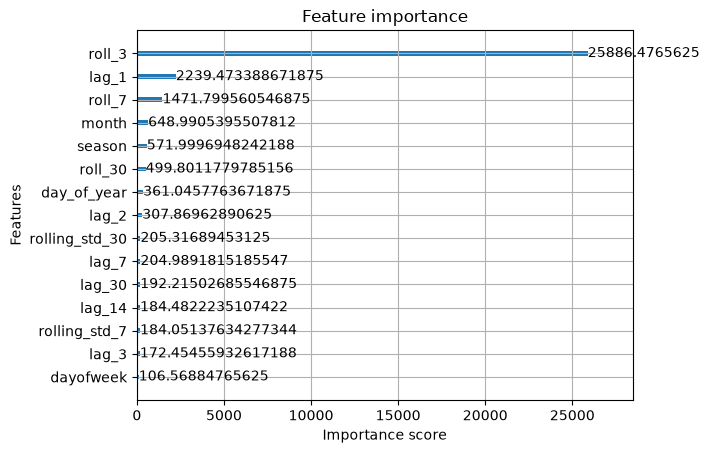

In [20]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model, importance_type="gain")
plt.show()

In [21]:
import os
import joblib

# حفظ النموذج وطباعة مكانه الدقيق
model_path = os.path.abspath("daily_xgb_model.joblib")
joblib.dump(model, model_path)
print("مكان الملف هو:", model_path)

مكان الملف هو: c:\Users\Shath\Desktop\python\smartwatt-backend\models\daily_xgb_model.joblib
